# 08 — Regional (epitope-level) benchmarking — CONFORMATIONAL track

Epitope-level evaluation for **conformational** (discontinuous) epitopes — the sibling of `07`.
Unit of analysis is one IEDB conformational epitope (a *set* of spatially-clustered residues,
not a contiguous span). Rebuilt from the residue layer + conformational ground truth + AlphaFold
PDBs, so the fair operating point and the controls below are available.

**Design (mirrors 07):**

- **Operating point:** matched budget (top-N per protein, N = union of conformational epitope
  residues). Native cutoff shown only for reference.
- **Recall is per-epitope**, over the residues the model actually scored.
- **Precision is per-protein** (positive calls inside any epitope ÷ all positive calls).
- **Tolerance is purely spatial** — there is no sequence neighbour for a discontinuous epitope.
  The single knob is **d Å**: a true residue *e* is recovered if a matched-budget positive lies
  within d Å (Cβ–Cβ) of *e*. **d = 0 is exact residue match** (the conformational analogue of k=0).
  d is swept over `D_VALUES`.
- **No fixed 25% rule.** The old `epitope_recovered = spatial_recall > 0.25` at a fixed 6 Å is
  replaced by the D(τ) sweep (area under D(τ) = mean recall) plus the d-sweep.
- **Fair subset:** proteins covered by every model.

**Lesson carried over from the linear track (important).** Spatial-tolerance recall *rewards
prediction spread*: at larger d a scattered random baseline blankets the surface and beats
concentrated real predictions, so raw tolerant recall can invert into an artefact. Conformational
is more exposed to this because everything is spatial. So a **random-null baseline is built in**;
report **gain above null**, not raw recall, for any d > 0. Headline on **d = 0**; treat d = 4 as
"absorbs annotation/structural-boundary noise"; expect **d ≥ 6–8 to degenerate** (random ≈ ceiling)
— shown and labelled, not hidden.

**Extensibility.** Add a model: drop its conformational `{folder}_indexed.csv` in place and add one
line to `MODELS`; re-run.

*Not executed here (data on BlueBEAR). Verify the CONFIG block matches your layout, then run.*

In [1]:
import ast
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# ===================== CONFIG (edit here only) =====================
ORGS = ["ESKAPE", "GAST", "INTRA", "RESP"]
TYPE = "conformational"

# display name -> output folder. ADD NEW MODELS HERE.
MODELS = {
    "BepiPred":  "bepipred3",
    "DiscoTope": "discotope3",
    "ElliPro":   "ellipro",
    "GraphBepi": "graphbepi",
    "SEMAi":     "sema",
    "RoBep":      "robep",
    "BepiPred2": "bepipred2",
}
MODEL_LIST = list(MODELS)

PRED = Path("../outputs")
GT = Path("../iedb")
STRUCTURE_BASE = Path("../structures")   # PDBs: STRUCTURE_BASE/{org}/conformational/{uniprot}.pdb  -- SET TO YOUR ROOT

# residue indexed-CSV columns (score unified; DiscoTope's score == calibrated_score)
COL_UNIPROT = "uniprot"
COL_RES = "res_index"
COL_SCORE = "score"
COL_YPRED = "y_pred"

# IEDB conformational ground-truth columns
GT_ID = "iedb_id"
GT_UNI = "uniprot_accession"
GT_RESSET = "residue_set"

TAUS = np.linspace(0.0, 1.0, 101)
DET_POINTS = [0.25, 0.50, 0.75]

D_VALUES = [0, 4, 6, 8]   # spatial-tolerance sweep (Angstrom, Cb-Cb)
PATCH_D = 4             # distance for the supplementary spatial-overlap heatmap
N_PERM = 20               # permutations for the random-null baseline (lower for speed)
# ==================================================================


## 1. Load residue-level predictions (conformational)

In [2]:
res_dfs, skipped = [], []
for name, folder in MODELS.items():
    for org in ORGS:
        path = PRED / folder / org / TYPE / f"{folder}_indexed.csv"
        if not path.exists():
            skipped.append((name, org))
            continue
        df = pd.read_csv(path)[[COL_UNIPROT, COL_RES, COL_SCORE, COL_YPRED]].copy()
        df.columns = ["uniprot", "res_index", "score", "y_pred"]
        df["uniprot"] = df["uniprot"].astype(str).str.strip()
        df["model"] = name
        df["organism"] = org
        res_dfs.append(df)

res = pd.concat(res_dfs, ignore_index=True)
print("residue rows:", res.shape)
if skipped:
    print("Missing (model, org):", skipped)


residue rows: (116851, 6)


## 2. Load conformational epitopes and derive residue truth

Each conformational epitope is a discontinuous *set* of residues (`residue_set`, ast-parsed).
Residue-level `y_true` is the union of all epitope residue-sets on a protein — used for the matched
budget and per-protein precision. Per-epitope residue sets are kept for per-epitope recall.

In [3]:
def parse_residue_set(x):
    if pd.isna(x):
        return []
    try:
        return sorted(set(int(v) for v in ast.literal_eval(str(x))))
    except Exception:
        return []

def load_epitopes(org):
    g = pd.read_csv(GT / org / TYPE / f"{TYPE}_ground_truth.csv")
    rows = []
    for i, r in g.iterrows():
        residues = tuple(parse_residue_set(r[GT_RESSET]))
        if not residues:
            continue
        rows.append({"uniprot": str(r[GT_UNI]).strip(),
                     "iedb_id": r[GT_ID] if GT_ID in g.columns else i,
                     "residues": residues, "organism": org})
    return pd.DataFrame(rows)

epitopes = pd.concat([load_epitopes(o) for o in ORGS], ignore_index=True)
epitopes["epitope_length"] = epitopes["residues"].apply(len)
print("epitopes:", epitopes.shape)

true_res = set()
for e in epitopes.itertuples():
    for r in e.residues:
        true_res.add((e.uniprot, r))
res["y_true"] = [(u, r) in true_res for u, r in zip(res["uniprot"], res["res_index"])]
res["y_true"] = res["y_true"].astype(int)
print("residue prevalence (pooled):", round(res["y_true"].mean(), 4))


epitopes: (148, 5)
residue prevalence (pooled): 0.0537


## 3. Sanity checks

In [4]:
dups = res.duplicated(["model", "uniprot", "res_index"]).sum()
print("duplicate (model,uniprot,res_index) rows:", dups)

cov = (res.groupby("model")
       .agg(proteins=("uniprot", "nunique"), residues=("res_index", "size"),
            positives=("y_true", "sum")).reset_index())
cov["prevalence"] = (cov["positives"] / cov["residues"]).round(4)
print(cov.to_string(index=False))

print("\nScore-orientation (mean score on positives should exceed negatives):")
for m, sub in res.groupby("model"):
    pos = sub.loc[sub.y_true == 1, "score"].mean()
    neg = sub.loc[sub.y_true == 0, "score"].mean()
    flag = "   <-- CHECK ORIENTATION" if pos < neg else ""
    print(f"  {m:10s} mean(score|pos)={pos:.3f}  mean(score|neg)={neg:.3f}{flag}")


duplicate (model,uniprot,res_index) rows: 0
    model  proteins  residues  positives  prevalence
 BepiPred        38     17223        904      0.0525
BepiPred2        38     17223        904      0.0525
DiscoTope        38     17223        904      0.0525
  ElliPro        38     17223        904      0.0525
GraphBepi        36     13513        850      0.0629
    RoBep        38     17223        904      0.0525
    SEMAi        38     17223        904      0.0525

Score-orientation (mean score on positives should exceed negatives):
  BepiPred   mean(score|pos)=0.112  mean(score|neg)=0.065
  BepiPred2  mean(score|pos)=0.526  mean(score|neg)=0.526
  DiscoTope  mean(score|pos)=0.528  mean(score|neg)=0.163
  ElliPro    mean(score|pos)=0.482  mean(score|neg)=0.491   <-- CHECK ORIENTATION
  GraphBepi  mean(score|pos)=0.139  mean(score|neg)=0.082
  RoBep      mean(score|pos)=0.141  mean(score|neg)=0.050
  SEMAi      mean(score|pos)=0.728  mean(score|neg)=0.548


## 4. Fair subset (proteins covered by every model)

In [5]:
prot_sets = [set(res.loc[res.model == m, "uniprot"].unique()) for m in MODEL_LIST]
common_prot = set.intersection(*prot_sets)
res_fair = res[res["uniprot"].isin(common_prot)].copy()
epitopes_fair = epitopes[epitopes["uniprot"].isin(common_prot)].copy()
print("common proteins:", len(common_prot))
print("epitopes in fair subset:", len(epitopes_fair))
print(res_fair.groupby("model").size())


common proteins: 36
epitopes in fair subset: 145
model
BepiPred     13513
BepiPred2    13513
DiscoTope    13513
ElliPro      13513
GraphBepi    13513
RoBep        13513
SEMAi        13513
dtype: int64


## 5. Operating point — matched budget

In [6]:
def add_matched_budget(df):
    df = df.copy()
    df["y_pred_matched"] = 0
    for _, sub in df.groupby(["model", "uniprot"]):
        n_true = int(sub["y_true"].sum())
        if n_true > 0:
            idx = sub.sort_values("score", ascending=False).head(n_true).index
            df.loc[idx, "y_pred_matched"] = 1
    return df

res_fair = add_matched_budget(res_fair)
print("matched-budget positives per model:")
print(res_fair.groupby("model")["y_pred_matched"].sum())


matched-budget positives per model:
model
BepiPred     850
BepiPred2    850
DiscoTope    850
ElliPro      850
GraphBepi    850
RoBep        850
SEMAi        850
Name: y_pred_matched, dtype: int64


## 6. Cβ coordinates from AlphaFold PDBs

One Cβ per residue (Cα for glycine), single-chain models assumed (PDB residue number = res_index).

In [7]:
def parse_cb_coords(pdb_file):
    coords = {}
    with open(pdb_file) as fh:
        for line in fh:
            if not line.startswith("ATOM"):
                continue
            atom = line[12:16].strip()
            resname = line[17:20].strip()
            if atom == "CB" or (atom == "CA" and resname == "GLY"):
                resi = int(line[22:26])
                coords[resi] = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return coords

COORDS = {}
missing_pdb = []
for org, uni in epitopes_fair[["organism", "uniprot"]].drop_duplicates().itertuples(index=False):
    pdb_file = STRUCTURE_BASE / org / TYPE / f"{uni}.pdb"
    if not pdb_file.exists():
        missing_pdb.append((org, uni))
        continue
    COORDS[(org, uni)] = parse_cb_coords(pdb_file)
print("proteins with coordinates:", len(COORDS))
if missing_pdb:
    print("missing PDBs:", len(missing_pdb), "e.g.", missing_pdb[:5])


proteins with coordinates: 36


## 7. Per-epitope spatial recall — min-distance, then threshold

For each true epitope residue we compute the **minimum distance to any matched-budget positive**
once (0 if the residue is itself positive). Recall at tolerance d is then the fraction of an
epitope's residues whose min-distance ≤ d. Computing the distance once and thresholding at every d
is exact and fast. **d = 0 = exact match.**

Mean per-epitope recall vs spatial tolerance d (matched budget):
d              0      4      6      8
model                                
BepiPred   0.116  0.118  0.232  0.300
BepiPred2  0.056  0.057  0.125  0.180
DiscoTope  0.164  0.181  0.362  0.439
ElliPro    0.064  0.065  0.139  0.160
GraphBepi  0.181  0.185  0.308  0.394
RoBep      0.207  0.216  0.361  0.421
SEMAi      0.136  0.138  0.219  0.250


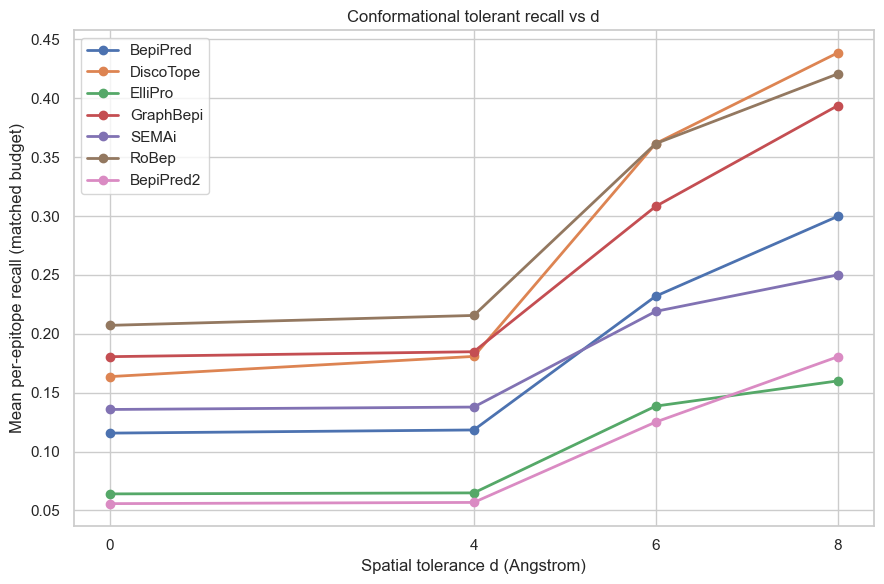

In [8]:
def per_residue_mindist(res_df, epi_df, coords, pred_col):
    scored = res_df.groupby(["model", "uniprot"])["res_index"].apply(set).to_dict()
    posmap = (res_df[res_df[pred_col] == 1]
              .groupby(["model", "uniprot"])["res_index"].apply(set).to_dict())
    rows, Pcache = [], {}
    for m in MODEL_LIST:
        for e in epi_df.itertuples():
            key = (m, e.uniprot)
            sc = scored.get(key, set())
            es = [r for r in e.residues if r in sc]
            if not es:
                continue
            p = posmap.get(key, set())
            cmap = coords.get((e.organism, e.uniprot), {})
            if key not in Pcache:
                Pcache[key] = (np.array([cmap[q] for q in p if q in cmap])
                               if (p and cmap) else np.empty((0, 3)))
            P = Pcache[key]
            for r in es:
                if r in p:
                    md = 0.0
                elif r in cmap and len(P):
                    md = float(np.min(np.linalg.norm(P - cmap[r], axis=1)))
                else:
                    md = np.inf
                rows.append({"model": m, "organism": e.organism, "uniprot": e.uniprot,
                             "iedb_id": e.iedb_id, "residue": r, "mindist": md})
    return pd.DataFrame(rows)

def recall_at_d(mindist_df, d):
    md = mindist_df.assign(rec=(mindist_df["mindist"] <= d).astype(float))
    return (md.groupby(["model", "organism", "uniprot", "iedb_id"])["rec"]
            .mean().reset_index().rename(columns={"rec": "recall"}))

mindist = per_residue_mindist(res_fair, epitopes_fair, COORDS, "y_pred_matched")

sweep = pd.concat([recall_at_d(mindist, d).assign(d=d) for d in D_VALUES], ignore_index=True)
sweep_summary = (sweep.groupby(["model", "d"])["recall"].mean()
                 .reset_index().pivot(index="model", columns="d", values="recall"))
print(f"Mean per-epitope recall vs spatial tolerance d (matched budget):")
print(sweep_summary.round(3).to_string())

ep_exact = recall_at_d(mindist, 0)   # per-epitope recall at d=0 (headline)

plt.figure(figsize=(9, 6))
for m in MODEL_LIST:
    plt.plot(D_VALUES, [sweep_summary.loc[m, d] for d in D_VALUES], marker="o", lw=2, label=m)
plt.xlabel("Spatial tolerance d (Angstrom)")
plt.ylabel("Mean per-epitope recall (matched budget)")
plt.title("Conformational tolerant recall vs d")
plt.xticks(D_VALUES)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Random baseline — is the tolerance gain real?

Same control as the linear track. Random matched-budget selection (no signal, same budget,
structure, epitopes, tolerance), averaged over `N_PERM` permutations, gives the recall tolerance
hands out for free. **Gain above null = actual − null** is the diagnostic; raw recall rises for
random too, and faster, because scattered guesses' spheres blanket more surface than a concentrated
prediction's overlapping spheres. Report gain-above-null, not raw recall, for any d > 0.

Tolerant recall vs random null (N_PERM=20):
    model  d  actual  null_mean  null_sd  gain_above_null      z
 BepiPred  0   0.116      0.110    0.022            0.005  0.240
 BepiPred  4   0.118      0.122    0.024           -0.003 -0.135
 BepiPred  6   0.232      0.381    0.048           -0.149 -3.081
 BepiPred  8   0.300      0.539    0.043           -0.239 -5.580
BepiPred2  0   0.056      0.099    0.021           -0.043 -2.097
BepiPred2  4   0.057      0.111    0.025           -0.054 -2.166
BepiPred2  6   0.125      0.367    0.037           -0.242 -6.629
BepiPred2  8   0.180      0.539    0.043           -0.358 -8.283
DiscoTope  0   0.164      0.111    0.024            0.053  2.250
DiscoTope  4   0.181      0.125    0.023            0.056  2.428
DiscoTope  6   0.362      0.381    0.040           -0.019 -0.479
DiscoTope  8   0.439      0.547    0.047           -0.109 -2.290
  ElliPro  0   0.064      0.102    0.023           -0.038 -1.627
  ElliPro  4   0.065      0.114    0.022      

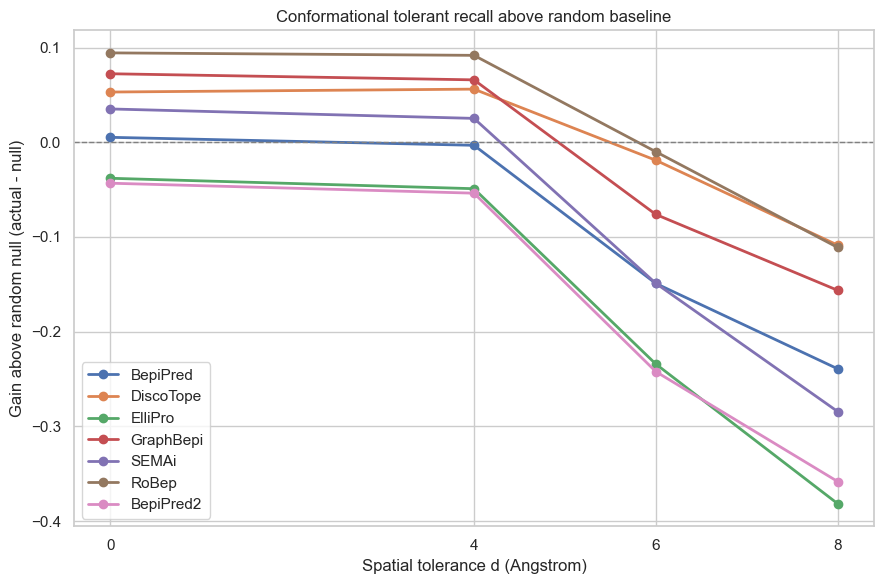

In [9]:
def random_matched_pred(res_df, rng):
    df = res_df.copy()
    df["y_pred_random"] = 0
    for _, sub in df.groupby(["model", "uniprot"]):
        n = int(sub["y_true"].sum())
        if n > 0:
            pick = rng.choice(sub.index.values, size=min(n, len(sub)), replace=False)
            df.loc[pick, "y_pred_random"] = 1
    return df

null_rows = []
for b in range(N_PERM):
    rng_b = np.random.default_rng(2000 + b)
    rnd = random_matched_pred(res_fair, rng_b)
    md_null = per_residue_mindist(rnd, epitopes_fair, COORDS, "y_pred_random")
    for d in D_VALUES:
        g = recall_at_d(md_null, d).groupby("model")["recall"].mean()
        for m in MODEL_LIST:
            null_rows.append({"perm": b, "model": m, "d": d, "recall": g[m]})
null_df = pd.DataFrame(null_rows)

null_stats = (null_df.groupby(["model", "d"])["recall"]
              .agg(null_mean="mean", null_sd="std").reset_index())
actual = (sweep.groupby(["model", "d"])["recall"].mean()
          .reset_index().rename(columns={"recall": "actual"}))
comp = actual.merge(null_stats, on=["model", "d"])
comp["gain_above_null"] = comp["actual"] - comp["null_mean"]
comp["z"] = (comp["actual"] - comp["null_mean"]) / comp["null_sd"].replace(0, np.nan)

print(f"Tolerant recall vs random null (N_PERM={N_PERM}):")
print(comp.round(3).to_string(index=False))

plt.figure(figsize=(9, 6))
for m in MODEL_LIST:
    s = comp[comp.model == m].sort_values("d")
    plt.plot(s["d"], s["gain_above_null"], marker="o", lw=2, label=m)
plt.axhline(0, color="gray", ls="--", lw=1)
plt.xlabel("Spatial tolerance d (Angstrom)")
plt.ylabel("Gain above random null (actual - null)")
plt.title("Conformational tolerant recall above random baseline")
plt.xticks(D_VALUES)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/cp/75kstzzx29xbkmz2xf3rg4xm0000gn/T/ipykernel_10247/2545156553.py:305: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


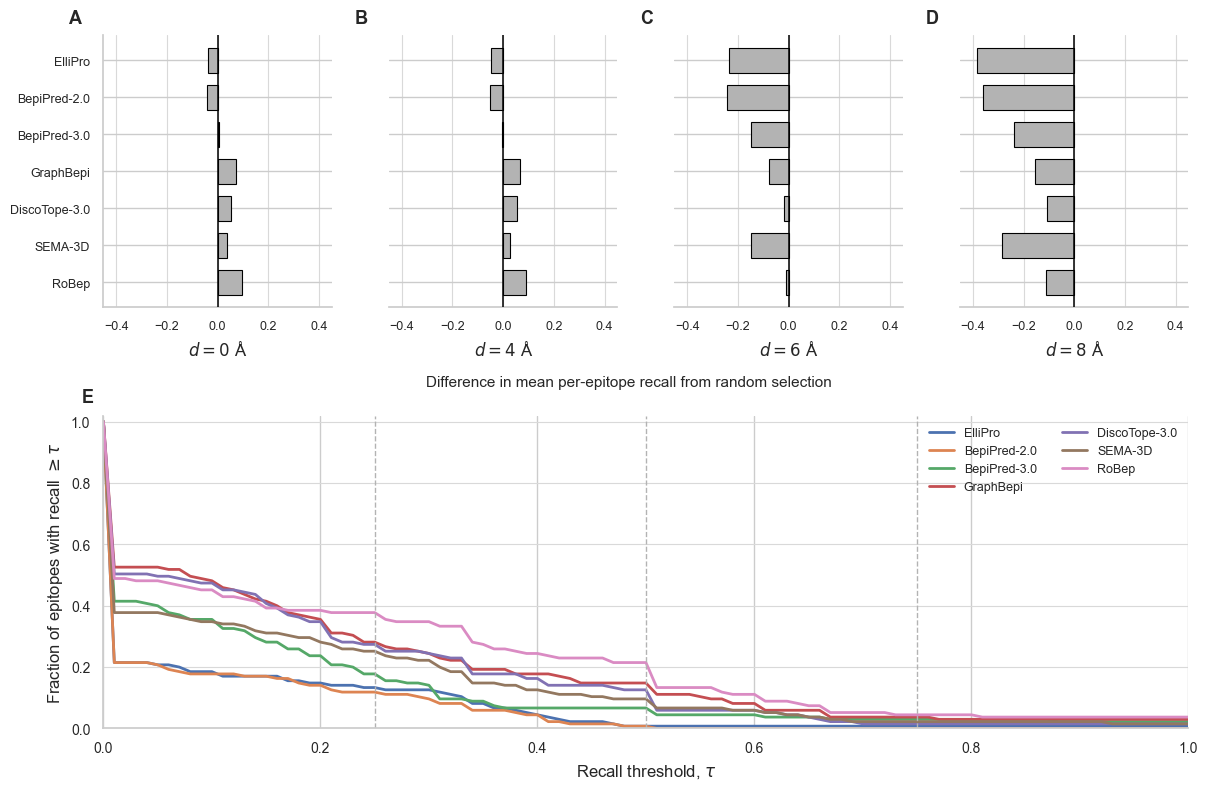

Mean exact recall vs area under detection-rate curve:
ElliPro         mean recall = 0.064   area = 0.068
BepiPred-2.0    mean recall = 0.056   area = 0.060
BepiPred-3.0    mean recall = 0.116   area = 0.119
GraphBepi       mean recall = 0.181   area = 0.184
DiscoTope-3.0   mean recall = 0.164   area = 0.167
SEMA-3D         mean recall = 0.136   area = 0.140
RoBep           mean recall = 0.207   area = 0.211


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---------------------------------------------------------
# Clean predictor names and fixed order
# ---------------------------------------------------------
model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep"
}

predictor_order_raw = [
    "ElliPro",
    "BepiPred2",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep"
]

# Same predictor colours as the linear figure
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {
    m: default_colors[i % len(default_colors)]
    for i, m in enumerate(predictor_order_raw)
}

# ---------------------------------------------------------
# Random matched predictions
# ---------------------------------------------------------
def random_matched_pred(res_df, rng):
    df = res_df.copy()
    df["y_pred_random"] = 0

    for _, sub in df.groupby(["model", "uniprot"]):
        n = int(sub["y_true"].sum())

        if n > 0:
            pick = rng.choice(
                sub.index.values,
                size=min(n, len(sub)),
                replace=False
            )
            df.loc[pick, "y_pred_random"] = 1

    return df

# ---------------------------------------------------------
# Random-selection baseline
# ---------------------------------------------------------
null_rows = []

for b in range(N_PERM):
    rng_b = np.random.default_rng(2000 + b)
    rnd = random_matched_pred(res_fair, rng_b)

    md_null = per_residue_mindist(
        rnd,
        epitopes_fair,
        COORDS,
        "y_pred_random"
    )

    for d in D_VALUES:
        g = (
            recall_at_d(md_null, d)
            .groupby("model")["recall"]
            .mean()
        )

        for m in MODEL_LIST:
            null_rows.append({
                "perm": b,
                "model": m,
                "d": d,
                "recall": g[m]
            })

null_df = pd.DataFrame(null_rows)

null_stats = (
    null_df
    .groupby(["model", "d"])["recall"]
    .agg(random_mean="mean", random_sd="std")
    .reset_index()
)

actual = (
    sweep
    .groupby(["model", "d"])["recall"]
    .mean()
    .reset_index()
    .rename(columns={"recall": "observed"})
)

comp = actual.merge(
    null_stats,
    on=["model", "d"]
)

comp["difference_from_random"] = (
    comp["observed"] - comp["random_mean"]
)

# ---------------------------------------------------------
# Conformational detection-rate curve at d = 0 Å
# ---------------------------------------------------------
def detection_curve(rec_df, taus):
    rows = []

    for m, sub in rec_df.groupby("model"):
        r = sub["recall"].dropna().values

        for t in taus:
            rows.append({
                "model": m,
                "tau": t,
                "detection_rate": float((r >= t).mean())
            })

    return pd.DataFrame(rows)

curve = detection_curve(ep_exact, TAUS)

# ---------------------------------------------------------
# Figure: A-D spatial tolerances, E detection curve
# ---------------------------------------------------------
fig = plt.figure(figsize=(14, 9))

gs = gridspec.GridSpec(
    2, 4,
    height_ratios=[1, 1.15],
    hspace=0.37,
    wspace=0.25
)

axes_top = [
    fig.add_subplot(gs[0, i])
    for i in range(4)
]

ax_det = fig.add_subplot(gs[1, :])

# Use identical limits across A-D
max_abs = np.abs(comp["difference_from_random"]).max()
xlim = max_abs * 1.18

panel_labels = ["A", "B", "C", "D"]

for ax, d, panel in zip(
    axes_top,
    D_VALUES,
    panel_labels
):
    sub = (
        comp[comp["d"] == d]
        .set_index("model")
        .reindex(predictor_order_raw)
        .reset_index()
    )

    values = sub["difference_from_random"].values
    y = np.arange(len(predictor_order_raw))

    ax.barh(
        y,
        values,
        height=0.68,
        facecolor="0.70",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    # Zero = same mean recovery as random selection
    ax.axvline(
        0,
        color="black",
        linewidth=1.1,
        zorder=4
    )

    ax.set_yticks(y)

    if ax is axes_top[0]:
        ax.set_yticklabels(
            [model_names[m] for m in predictor_order_raw]
        )
    else:
        ax.set_yticklabels([])

    ax.invert_yaxis()
    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel(rf"$d = {d}$ Å")

    # Only vertical grid lines in A-D
    ax.grid(
        axis="x",
        color="0.85",
        linewidth=0.8,
        zorder=0
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax is not axes_top[0]:
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)

    ax.tick_params(axis="both", labelsize=9)

    ax.text(
        -0.15,
        1.03,
        panel,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="bottom"
    )

# Shared x-axis description for A-D
fig.text(
    0.5,
    0.495,
    "Difference in mean per-epitope recall from random selection",
    ha="center",
    va="center",
    fontsize=11
)

# ---------------------------------------------------------
# Panel E: conformational detection-rate curve at d = 0 Å
# ---------------------------------------------------------
for m in predictor_order_raw:
    s = (
        curve[curve["model"] == m]
        .sort_values("tau")
    )

    ax_det.plot(
        s["tau"],
        s["detection_rate"],
        linewidth=2,
        color=model_colors[m],
        label=model_names[m]
    )

# Reference recall thresholds
for p in DET_POINTS:
    ax_det.axvline(
        p,
        linestyle="--",
        color="0.70",
        linewidth=1
    )

ax_det.set_xlabel(r"Recall threshold, $\tau$")
ax_det.set_ylabel(r"Fraction of epitopes with recall $\geq \tau$")

ax_det.set_xlim(0, 1)
ax_det.set_ylim(0, 1.02)

# Horizontal grid only
ax_det.grid(
    axis="y",
    color="0.85",
    linewidth=0.8
)

ax_det.spines["top"].set_visible(False)
ax_det.spines["right"].set_visible(False)

ax_det.tick_params(
    axis="both",
    labelsize=10
)

ax_det.legend(
    frameon=False,
    fontsize=9,
    loc="upper right",
    ncol=2
)

ax_det.text(
    -0.02,
    1.03,
    "E",
    transform=ax_det.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

plt.tight_layout()

plt.savefig(
    "conformational_epitope_recovery_combined.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "conformational_epitope_recovery_combined.pdf",
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# Identity check: area under D(tau) should equal mean recall
# ---------------------------------------------------------
_trap = getattr(np, "trapezoid", getattr(np, "trapz", None))

print("Mean exact recall vs area under detection-rate curve:")

for m in predictor_order_raw:
    mean_r = ep_exact.loc[
        ep_exact["model"] == m,
        "recall"
    ].mean()

    s = curve[
        curve["model"] == m
    ].sort_values("tau")

    area = _trap(
        s["detection_rate"].values,
        s["tau"].values
    )

    print(
        f"{model_names[m]:15s} "
        f"mean recall = {mean_r:.3f}   "
        f"area = {area:.3f}"
    )

## 9. Per-protein precision (two-sided view)

At matched budget precision = recall by construction, so **native** precision is what exposes
over-prediction.

In [10]:
def protein_pr(res_df, pred_col):
    rows = []
    for (m, uni), sub in res_df.groupby(["model", "uniprot"]):
        ap = int((sub["y_true"] == 1).sum())
        if ap == 0:
            continue
        pp = int((sub[pred_col] == 1).sum())
        tp = int(((sub[pred_col] == 1) & (sub["y_true"] == 1)).sum())
        prec = tp / pp if pp else 0.0
        rec = tp / ap
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
        rows.append({"model": m, "uniprot": uni, "precision": prec, "recall": rec, "f1": f1})
    return pd.DataFrame(rows)

prot_native = protein_pr(res_fair, "y_pred")
prot_prec_summary = (prot_native.groupby("model")
                     .agg(mean_precision_native=("precision", "mean"),
                          mean_recall_native=("recall", "mean"),
                          mean_f1_native=("f1", "mean")).reset_index())
print("per-protein (native cutoff):")
print(prot_prec_summary.round(3).to_string(index=False))


per-protein (native cutoff):
    model  mean_precision_native  mean_recall_native  mean_f1_native
 BepiPred                  0.086               0.385           0.121
BepiPred2                  0.077               0.779           0.130
DiscoTope                  0.123               0.352           0.162
  ElliPro                  0.082               0.557           0.129
GraphBepi                  0.136               0.320           0.146
    RoBep                  0.178               0.116           0.121
    SEMAi                  0.091               0.704           0.151


## 10. Detection-rate sweep D(τ) at d = 0

D(τ) = fraction of epitopes with exact recall ≥ τ. Area under D(τ) = mean exact recall (checked).
Replaces the old fixed 25% rule; 0.25 is just one point on this curve.

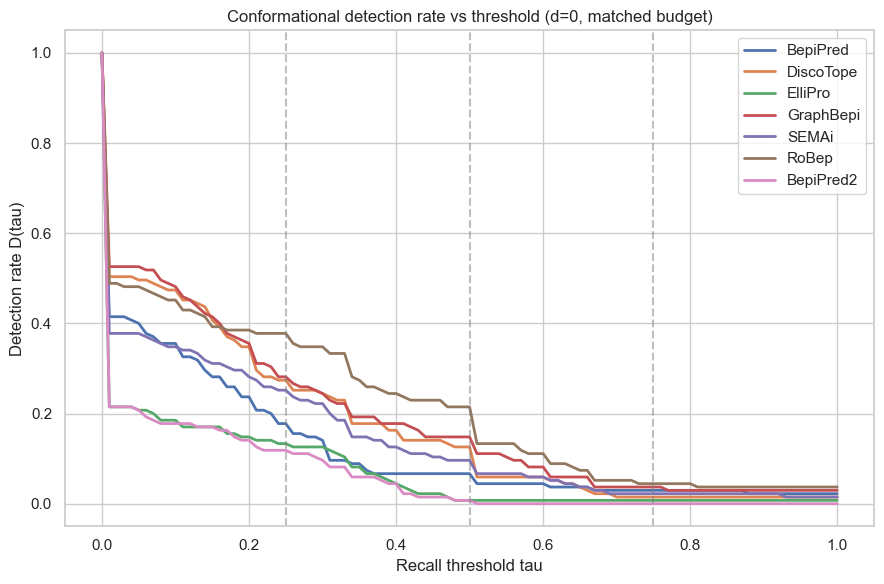

mean exact recall vs area under D(tau):
  BepiPred   mean=0.116  area=0.119
  DiscoTope  mean=0.164  area=0.167
  ElliPro    mean=0.064  area=0.068
  GraphBepi  mean=0.181  area=0.184
  SEMAi      mean=0.136  area=0.140
  RoBep      mean=0.207  area=0.211
  BepiPred2  mean=0.056  area=0.060


In [11]:
def detection_curve(rec_df, taus):
    rows = []
    for m, sub in rec_df.groupby("model"):
        r = sub["recall"].dropna().values
        for t in taus:
            rows.append({"model": m, "tau": t, "detection_rate": float((r >= t).mean())})
    return pd.DataFrame(rows)

curve = detection_curve(ep_exact, TAUS)
plt.figure(figsize=(9, 6))
for m in MODEL_LIST:
    s = curve[curve.model == m]
    plt.plot(s["tau"], s["detection_rate"], lw=2, label=m)
for p in DET_POINTS:
    plt.axvline(p, ls="--", color="gray", alpha=0.5)
plt.xlabel("Recall threshold tau")
plt.ylabel("Detection rate D(tau)")
plt.title("Conformational detection rate vs threshold (d=0, matched budget)")
plt.legend()
plt.tight_layout()
plt.show()

_trap = getattr(np, "trapezoid", getattr(np, "trapz", None))
print("mean exact recall vs area under D(tau):")
for m in MODEL_LIST:
    mean_r = ep_exact.loc[ep_exact.model == m, "recall"].mean()
    s = curve[curve.model == m].sort_values("tau")
    print(f"  {m:10s} mean={mean_r:.3f}  area={_trap(s['detection_rate'].values, s['tau'].values):.3f}")


## 11. Headline summary table

In [12]:
det_at = {p: ep_exact.groupby("model")["recall"].apply(lambda r: (r >= p).mean())
          for p in DET_POINTS}
gain_d4 = comp[comp.d == 4].set_index("model")["gain_above_null"]

summary = pd.DataFrame({
    "n_epitopes": ep_exact.groupby("model").size(),
    "mean_recall_d0": ep_exact.groupby("model")["recall"].mean(),
    "gain_above_null_d4": gain_d4,
})
for p in DET_POINTS:
    summary[f"det@{p:.2f}"] = det_at[p]
summary = summary.merge(prot_prec_summary.set_index("model")[["mean_precision_native"]],
                        left_index=True, right_index=True).reset_index().rename(columns={"index": "model"})

print("CONFORMATIONAL REGIONAL SUMMARY")
print(summary.round(3).to_string(index=False))
print("\nRanking by exact (d=0) per-epitope recall:")
print(summary.sort_values("mean_recall_d0", ascending=False)
      [["model", "mean_recall_d0", "gain_above_null_d4"]].round(3).to_string(index=False))


CONFORMATIONAL REGIONAL SUMMARY
    model  n_epitopes  mean_recall_d0  gain_above_null_d4  det@0.25  det@0.50  det@0.75  mean_precision_native
 BepiPred         135           0.116              -0.003     0.178     0.067     0.030                  0.086
BepiPred2         135           0.056              -0.054     0.119     0.007     0.000                  0.077
DiscoTope         135           0.164               0.056     0.274     0.126     0.015                  0.123
  ElliPro         135           0.064              -0.049     0.133     0.007     0.007                  0.082
GraphBepi         135           0.181               0.066     0.281     0.148     0.037                  0.136
    RoBep         135           0.207               0.092     0.378     0.215     0.044                  0.178
    SEMAi         135           0.136               0.025     0.252     0.096     0.022                  0.091

Ranking by exact (d=0) per-epitope recall:
    model  mean_recall_d0  gain_abov

## 12. Recall distribution (d = 0)

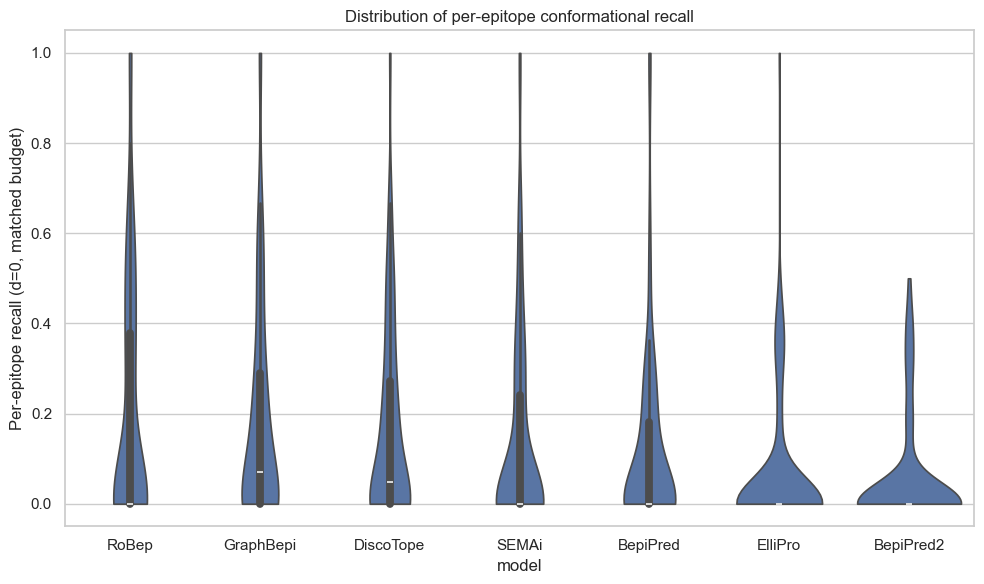

In [13]:
order = summary.sort_values("mean_recall_d0", ascending=False)["model"]
plt.figure(figsize=(10, 6))
sns.violinplot(data=ep_exact, x="model", y="recall", order=order, cut=0)
plt.ylabel("Per-epitope recall (d=0, matched budget)")
plt.title("Distribution of per-epitope conformational recall")
plt.tight_layout()
plt.show()


## 13. Per-protein winners (d = 0)

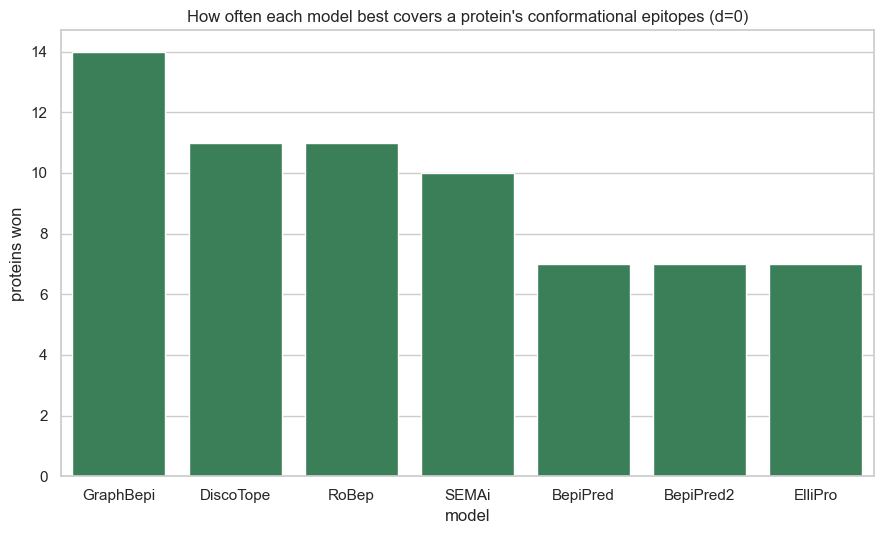

    model  wins
GraphBepi    14
DiscoTope    11
    RoBep    11
    SEMAi    10
 BepiPred     7
BepiPred2     7
  ElliPro     7


In [14]:
prot_perf = ep_exact.groupby(["model", "uniprot"])["recall"].mean().reset_index()
best = prot_perf.groupby("uniprot")["recall"].transform("max")
winners = prot_perf[np.isclose(prot_perf["recall"], best)]
winner_counts = winners.groupby("model").size().reset_index(name="wins")
plt.figure(figsize=(9, 5.5))
sns.barplot(data=winner_counts.sort_values("wins", ascending=False), x="model", y="wins", color="seagreen")
plt.title("How often each model best covers a protein's conformational epitopes (d=0)")
plt.ylabel("proteins won")
plt.tight_layout()
plt.show()
print(winner_counts.sort_values("wins", ascending=False).to_string(index=False))


## 14. Supplementary — inter-model agreement

These measure model *redundancy*, not performance. Prediction overlap and spatial patch overlap use
**matched-budget** predictions (equal set sizes, so overlap reflects genuine agreement rather than
calibration); score correlation uses Spearman (rank-based, robust to differing score scales).

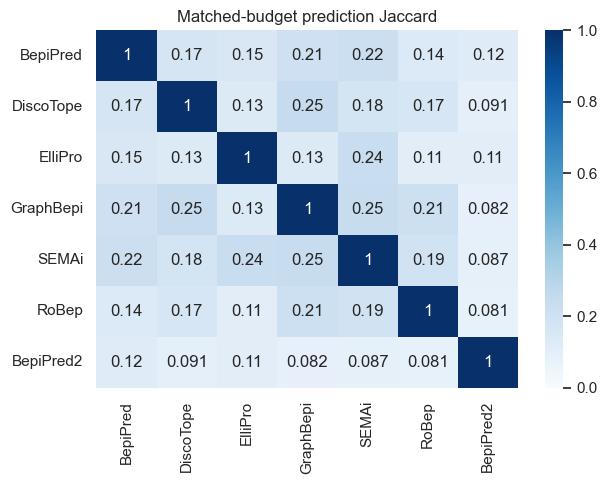

In [15]:
# matched-budget positive sets per model (global)
pos_sets = {m: set(map(tuple, res_fair[(res_fair.model == m) & (res_fair.y_pred_matched == 1)]
                       [["uniprot", "res_index"]].values)) for m in MODEL_LIST}

jac = pd.DataFrame(np.eye(len(MODEL_LIST)), index=MODEL_LIST, columns=MODEL_LIST)
for a, b in combinations(MODEL_LIST, 2):
    inter = len(pos_sets[a] & pos_sets[b]); union = len(pos_sets[a] | pos_sets[b])
    j = inter / union if union else np.nan
    jac.loc[a, b] = jac.loc[b, a] = j

plt.figure(figsize=(6.5, 5))
sns.heatmap(jac.astype(float), annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Matched-budget prediction Jaccard")
plt.tight_layout()
plt.show()


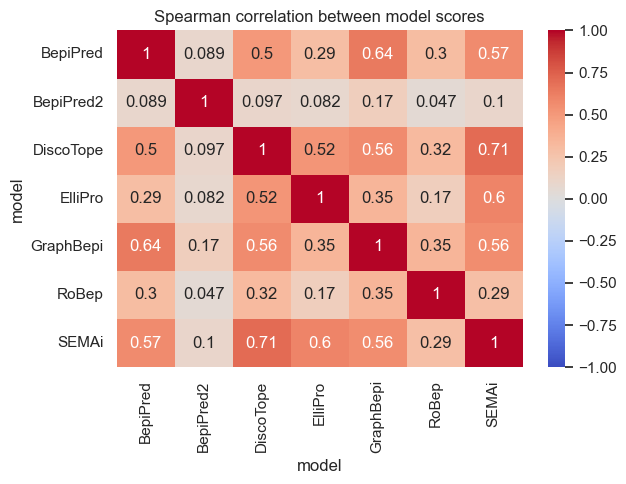

In [16]:
# Spearman correlation of raw scores across models
pivot = res_fair.pivot_table(index=["uniprot", "res_index"], columns="model", values="score")
spear = pivot.corr(method="spearman")
plt.figure(figsize=(6.5, 5))
sns.heatmap(spear, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman correlation between model scores")
plt.tight_layout()
plt.show()


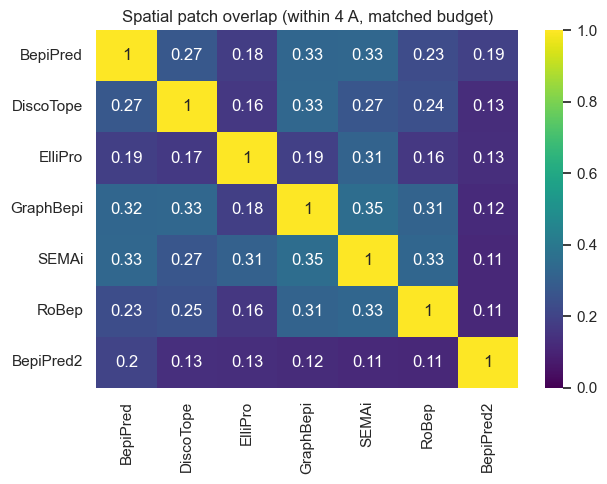

In [17]:
# spatial patch overlap: fraction of model A's matched positives within PATCH_D A of model B's
def patch_overlap(res_df, coords, d):
    posmap = (res_df[res_df.y_pred_matched == 1]
              .groupby(["model", "uniprot"])["res_index"].apply(set).to_dict())
    acc = {(a, b): [] for a in MODEL_LIST for b in MODEL_LIST}
    for uni in res_df["uniprot"].unique():
        org = res_df.loc[res_df.uniprot == uni, "organism"].iloc[0]
        cmap = coords.get((org, uni), {})
        if not cmap:
            continue
        psets = {m: posmap.get((m, uni), set()) for m in MODEL_LIST}
        for a in MODEL_LIST:
            for b in MODEL_LIST:
                src = [r for r in psets[a] if r in cmap]
                tgt = np.array([cmap[r] for r in psets[b] if r in cmap])
                if not src or not len(tgt):
                    continue
                hits = sum(np.min(np.linalg.norm(tgt - cmap[r], axis=1)) <= d for r in src)
                acc[(a, b)].append(hits / len(src))
    mat = pd.DataFrame(np.eye(len(MODEL_LIST)), index=MODEL_LIST, columns=MODEL_LIST)
    for (a, b), v in acc.items():
        if v:
            mat.loc[a, b] = np.mean(v)
    return mat

patch = patch_overlap(res_fair, COORDS, PATCH_D)
plt.figure(figsize=(6.5, 5))
sns.heatmap(patch.astype(float), annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title(f"Spatial patch overlap (within {PATCH_D} A, matched budget)")
plt.tight_layout()
plt.show()


## 15. Reporting notes & extensibility

- **Headline:** mean per-epitope recall at **d = 0** (matched budget) + D(τ) + distribution.
- **Tolerance + null:** report the d-sweep only as **gain above null**. Raw tolerant recall rises
  for random guessing too and faster; expect d ≥ 6–8 to degenerate (random ≈ ceiling) — state it.
- Report native-cutoff precision to show over-prediction; never rank models by native threshold metrics.
- **Do not compare** these conformational numbers against the linear track as the same metric —
  different prevalence, ground-truth nature, and tolerance units (Å vs residues).
- **Supplementary** agreement panels are about redundancy, not skill.
- **Add a model:** drop conformational `{folder}_indexed.csv` in place, add one line to `MODELS`, re-run.
- Single-chain AlphaFold models assumed (revisit for multi-chain viral antigens).

In [24]:
patch.to_csv("conformational_spatial_overlap.csv")

Consensus columns: ['min_predictors', 'predicted_positives', 'precision', 'recall']


/var/folders/cp/75kstzzx29xbkmz2xf3rg4xm0000gn/T/ipykernel_10247/2883898497.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


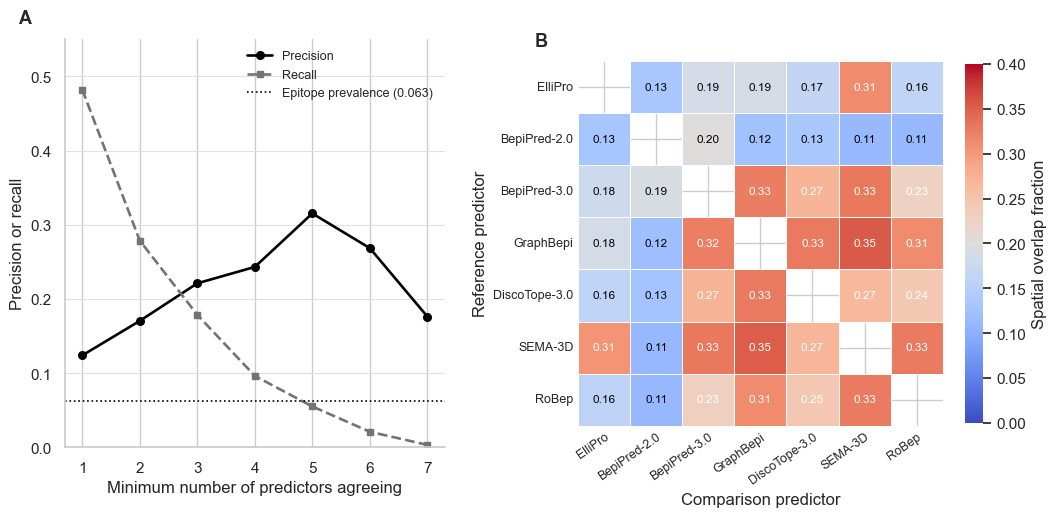

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

# ---------------------------------------------------------
# Load results produced by the two analysis notebooks
# ---------------------------------------------------------
cum = pd.read_csv("conformational_consensus.csv", dtype={"min_models_agree": int})
patch = pd.read_csv(
    "conformational_spatial_overlap.csv",
    index_col=0
)

# ---------------------------------------------------------
# Clean predictor names and fixed chronological order
# ---------------------------------------------------------
model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep"
}

predictor_order = [
    "ElliPro",
    "BepiPred2",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep"
]

predictor_labels = [model_names[m] for m in predictor_order]

# Keep matrix in the same predictor order
patch = patch.reindex(
    index=predictor_order,
    columns=predictor_order
)

patch.index = predictor_labels
patch.columns = predictor_labels

# Conformational prevalence from the benchmark
conf_prevalence = 0.063

# ---------------------------------------------------------
# Combined figure
# ---------------------------------------------------------
fig = plt.figure(figsize=(12.5, 5.3))

gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[1.0, 1.2],
    wspace=0.32
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# ---------------------------------------------------------
# A. Consensus precision and recall
# ---------------------------------------------------------

# Standardize column name in case an older CSV/version was used
if "min_models_agree" in cum.columns:
    cum = cum.rename(columns={"min_models_agree": "min_predictors"})

print("Consensus columns:", cum.columns.tolist())

ax1.plot(
    cum["min_predictors"],
    cum["precision"],
    marker="o",
    markersize=5.5,
    linewidth=1.9,
    color="black",
    label="Precision"
)

ax1.plot(
    cum["min_predictors"],
    cum["recall"],
    marker="s",
    markersize=5,
    linewidth=1.9,
    linestyle="--",
    color="0.45",
    label="Recall"
)

ax1.axhline(
    conf_prevalence,
    linestyle=":",
    linewidth=1.2,
    color="black",
    label=f"Epitope prevalence ({conf_prevalence:.3f})"
)

ax1.set_xlabel("Minimum number of predictors agreeing")
ax1.set_ylabel("Precision or recall")
ax1.set_xticks(cum["min_predictors"])
ax1.set_ylim(0, 0.55)

ax1.grid(
    axis="y",
    color="0.88",
    linewidth=0.8
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax1.legend(
    frameon=False,
    fontsize=9,
    loc="upper right"
)

ax1.text(
    -0.12,
    1.03,
    "A",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

# ---------------------------------------------------------
# B. Directional spatial overlap
# ---------------------------------------------------------

# Omit trivial self-comparisons
mask = np.eye(len(predictor_labels), dtype=bool)

off_diag = patch.values[~mask]
max_overlap = np.nanmax(off_diag)

# Shared sequential scale covering the observed values
heatmap_max = max(
    0.4,
    np.ceil(max_overlap * 10) / 10
)

# Draw coloured heatmap without automatic annotations
hm = sns.heatmap(
    patch.astype(float),
    ax=ax2,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    vmin=0,
    vmax=heatmap_max,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar=True,
    cbar_kws={
        "label": "Spatial overlap fraction",
        "shrink": 0.88
    }
)

# Add annotations manually so text remains readable
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):

        if mask[i, j] or pd.isna(patch.iloc[i, j]):
            continue

        value = patch.iloc[i, j]

        # White text on darker cells, black on lighter cells
        text_color = "white" if value > heatmap_max * 0.55 else "black"

        ax2.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_color
        )

ax2.set_xlabel("Comparison predictor")
ax2.set_ylabel("Reference predictor")

ax2.set_xticklabels(
    ax2.get_xticklabels(),
    rotation=35,
    ha="right",
    rotation_mode="anchor",
    fontsize=9
)

ax2.set_yticklabels(
    ax2.get_yticklabels(),
    rotation=0,
    fontsize=9
)

ax2.tick_params(
    axis="both",
    length=0
)

ax2.text(
    -0.12,
    1.03,
    "B",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

plt.tight_layout()

plt.savefig(
    "../figures/conformational_predictor_agreement.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "../figures/conformational_predictor_agreement.pdf",
    bbox_inches="tight"
)

plt.show()